Import Required Libraries

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
import io

Step 0: Download Image from Google Drive

In [27]:
# Convert Google Drive shareable link to direct download link
file_id = "1VtTbXEL-pYJiEmIyZawWv1ViXtQotWdx"
image_url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Download the image using requests
response = requests.get(image_url)
image = Image.open(io.BytesIO(response.content)).convert("RGB")
image = np.array(image)
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)  # Convert to BGR for OpenCV

Step 1: Load and Preprocess Image

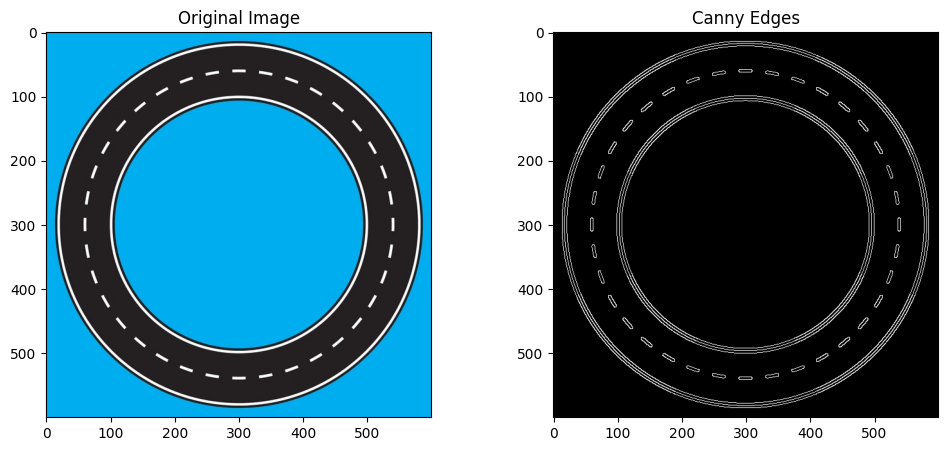

In [28]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Edge detection using Canny (required for line/circle fitting)
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

# Display original and edge-detected image
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); plt.title("Original Image")
plt.subplot(1, 2, 2); plt.imshow(edges, cmap='gray'); plt.title("Canny Edges")
plt.show()

Step 2: Complex Shape Fitting using Contour Approximation

In [36]:
# Find contours
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
complex_img = image.copy()
for cnt in contours:
    epsilon = 0.01 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    if len(approx) > 4 and cv2.contourArea(cnt) > 1000:
        cv2.drawContours(complex_img, [approx], 0, (255, 0, 255), 2)

Step 3: Show Fitted Results

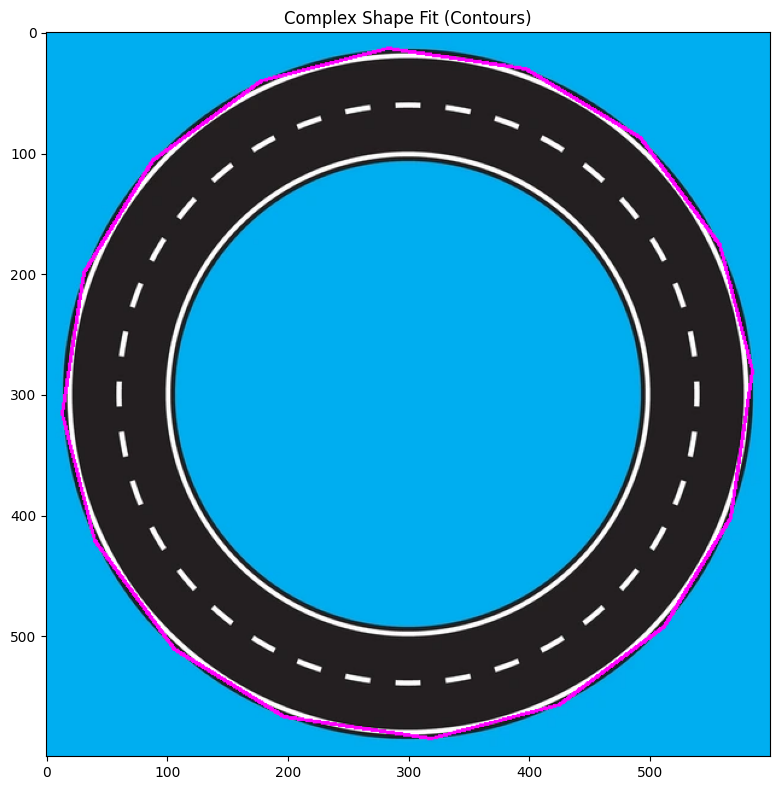

In [37]:
plt.figure(figsize=(15, 8))

plt.imshow(cv2.cvtColor(complex_img, cv2.COLOR_BGR2RGB))
plt.title("Complex Shape Fit (Contours)")

plt.tight_layout()
plt.show()